In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('user_journey_raw.csv')
data.head()

,user_id,session_id,subscription_type,user_journey
0,1516,2980231,Annual,Homepage-Log in-Log in-Log in-Log in-Log in-Lo...
1,1516,2980248,Annual,Other-Sign up-Sign up-Sign up-Sign up-Sign up-...
2,1516,2992252,Annual,Log in-Log in-Log in-Log in-Log in-Log in
3,1516,3070491,Annual,Homepage-Log in-Log in-Log in-Log in-Log in-Lo...
4,1516,3709807,Annual,Log in-Log in-Log in-Log in-Log in-Log in-Log ...


In [3]:
data.shape

(9935, 4)

In [4]:
data.columns

Index(['user_id', 'session_id', 'subscription_type', 'user_journey'], dtype='object')

In [5]:
data['user_journey'][0]

'Homepage-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Other'

In [6]:
data['user_journey'][90]

'Career tracks-Career track certificate-Career track certificate-Career track certificate-Career track certificate-Career tracks-Career tracks-Career tracks-Career track certificate-Career tracks-Career tracks-Career tracks-Career tracks-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses'

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9935 entries, 0 to 9934
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            9935 non-null   int64 
 1   session_id         9935 non-null   int64 
 2   subscription_type  9935 non-null   object
 3   user_journey       9935 non-null   object
dtypes: int64(2), object(2)
memory usage: 310.6+ KB


In [8]:
data.shape

(9935, 4)

In [9]:
total_users = data['user_id'].nunique()
print(f"Number of user are: {total_users}")

Number of user are: 1350


In [10]:
# Function to clean the user journey by removing all duplicates
def clean_user_journey(journey):
    if not journey:  # Handle empty journeys
        return ''
    
    # Split the journey into individual steps
    steps = journey.split('-')
    
    # Use a set to track seen steps and preserve order of first occurrence
    seen_steps = set()
    cleaned_steps = []
    for step in steps:
        if step not in seen_steps:
            cleaned_steps.append(step)
            seen_steps.add(step)
    
    # Join the cleaned steps back into a single string
    return '-'.join(cleaned_steps)


# Apply the cleaning function to the 'user_journey' column
data['cleaned_user_journey'] = data['user_journey'].apply(clean_user_journey)

In [11]:
data['user_journey'][0]

'Homepage-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Log in-Other'

In [12]:
data['cleaned_user_journey'][0]

'Homepage-Log in-Other'

In [13]:
data['user_journey'][80]

'Homepage-Career tracks-Career tracks-Career tracks-Career tracks-Career tracks-Homepage-Homepage-Homepage-Homepage-Homepage-Homepage-Homepage-Homepage-Homepage-Homepage-Homepage-Career tracks-Career tracks-Career tracks-Career tracks-Career tracks-Homepage-Homepage-Homepage-Career tracks-Homepage-Career tracks-Homepage-Homepage-Homepage-Pricing-Pricing-Pricing-Pricing-Pricing-Pricing-Pricing-Pricing-Sign up-Sign up-Sign up-Sign up-Sign up'

In [14]:
data['cleaned_user_journey'][80]

'Homepage-Career tracks-Pricing-Sign up'

In [15]:
data['user_journey'][90]

'Career tracks-Career track certificate-Career track certificate-Career track certificate-Career track certificate-Career tracks-Career tracks-Career tracks-Career track certificate-Career tracks-Career tracks-Career tracks-Career tracks-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses-Courses'

In [16]:
data['cleaned_user_journey'][90]

'Career tracks-Career track certificate-Courses'

In [17]:
# Split the cleaned journeys into individual steps
all_steps = data['cleaned_user_journey'].str.split('-').explode()

# Get unique steps
unique_steps = all_steps.unique()
print("Unique Steps:", unique_steps)

Unique Steps: ['Homepage' 'Log in' 'Other' 'Sign up' 'Checkout' 'Coupon' 'Pricing'
 'Career tracks' 'Resources center' 'Courses' 'Career track certificate'
 'Instructors' 'Course certificate' 'Success stories' 'Upcoming courses'
 'About us' 'Blog']


In [18]:
# Count occurrences of each step
step_counts = all_steps.value_counts()
print("Step Counts:\n", step_counts)

Step Counts:
 cleaned_user_journey
Log in                      3798
Homepage                    2396
Checkout                    2021
Other                       1535
Sign up                     1210
Coupon                      1041
Pricing                      929
Courses                      908
Career tracks                747
Career track certificate     355
Resources center             339
Course certificate           191
Upcoming courses             101
Success stories               49
Instructors                   26
About us                      22
Blog                          15
Name: count, dtype: int64


In [19]:
# Extract starting points
data['start_point'] = data['cleaned_user_journey'].apply(lambda x: x.split('-')[0] if x else None)

# Extract endpoints
data['end_point'] = data['cleaned_user_journey'].apply(lambda x: x.split('-')[-1] if x else None)

# Count occurrences of starting points
start_point_counts = data['start_point'].value_counts()
print("Start Point Counts:\n", start_point_counts)

Start Point Counts:
 start_point
Log in                      2379
Homepage                    2329
Checkout                    1776
Other                       1257
Coupon                      1013
Courses                      297
Pricing                      233
Career tracks                196
Sign up                      177
Resources center             169
Career track certificate      53
Course certificate            17
Instructors                   12
Upcoming courses               9
Success stories                8
About us                       6
Blog                           4
Name: count, dtype: int64


In [20]:
# Count occurrences of endpoints
end_point_counts = data['end_point'].value_counts()
print("End Point Counts:\n", end_point_counts)

End Point Counts:
 end_point
Log in                      3601
Checkout                    1964
Other                       1221
Coupon                      1029
Sign up                      883
Courses                      365
Pricing                      271
Career tracks                248
Career track certificate      88
Resources center              81
Homepage                      72
Course certificate            46
Upcoming courses              28
Success stories               19
About us                       9
Blog                           6
Instructors                    4
Name: count, dtype: int64


In [21]:
from collections import Counter

# Split journeys into lists of steps
journeys = data['cleaned_user_journey'].str.split('-')

# Count the frequency of each journey
journey_counts = Counter(tuple(journey) for journey in journeys)

# Display the top 10 most common journeys
top_journeys = journey_counts.most_common(10)
for journey, count in top_journeys:
    print(f"Journey: {'-'.join(journey)}, Count: {count}")

Journey: Log in, Count: 2257
Journey: Checkout, Count: 1773
Journey: Other, Count: 1012
Journey: Coupon, Count: 1003
Journey: Homepage-Log in, Count: 851
Journey: Homepage-Sign up, Count: 203
Journey: Homepage-Pricing, Count: 132
Journey: Sign up, Count: 125
Journey: Homepage-Courses, Count: 97
Journey: Resources center-Other, Count: 88


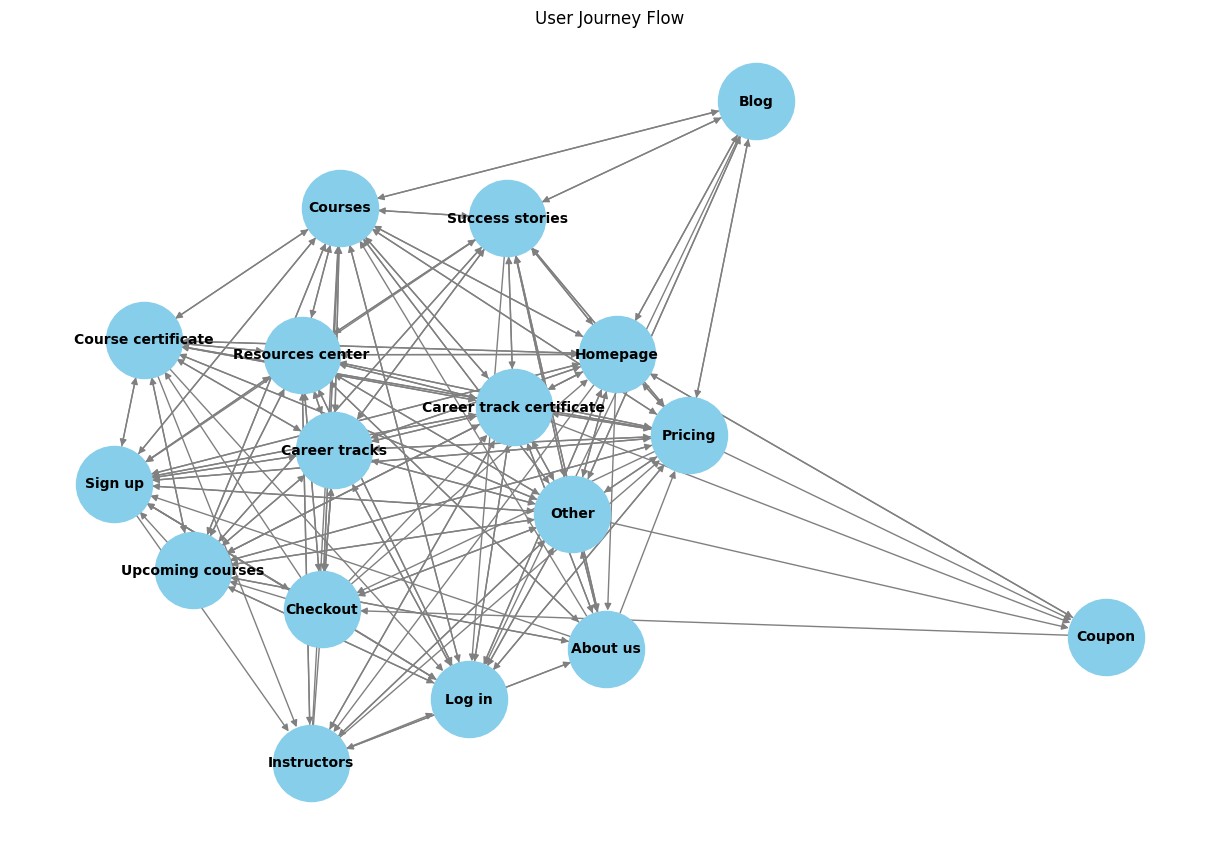

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges based on transitions between steps
for journey in journeys:
    for i in range(len(journey) - 1):
        G.add_edge(journey[i], journey[i + 1])

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # Layout for the graph
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", edge_color="gray")
plt.title("User Journey Flow")

# Save the graph as an image file (e.g., PNG)
plt.savefig('user_journey_flow.png', format='png', dpi=300)

# Show the graph
plt.show()

In [23]:
# Filter journeys that end with "Checkout"
conversion_journeys = data[data['end_point'] == 'Checkout']['cleaned_user_journey']

# Count the frequency of conversion paths
conversion_path_counts = Counter(conversion_journeys)

# Display the top 5 conversion paths
top_conversion_paths = conversion_path_counts.most_common(5)
for path, count in top_conversion_paths:
    print(f"Conversion Path: {path}, Count: {count}")

Conversion Path: Checkout, Count: 1773
Conversion Path: Pricing-Checkout, Count: 72
Conversion Path: Homepage-Pricing-Checkout, Count: 68
Conversion Path: Courses-Pricing-Checkout, Count: 7
Conversion Path: Other-Pricing-Checkout, Count: 3


In [24]:
# Group by subscription type and analyze journeys
grouped = data.groupby('subscription_type')['cleaned_user_journey'].agg(list)

# Analyze the top journeys for each subscription type
for subscription, journeys in grouped.items():
    journey_counts = Counter(journeys)
    top_journeys = journey_counts.most_common(5)
    print(f"Subscription Type: {subscription}")
    for journey, count in top_journeys:
        print(f"  Journey: {journey}, Count: {count}")

Subscription Type: Annual
  Journey: Log in, Count: 1399
  Journey: Coupon, Count: 932
  Journey: Checkout, Count: 898
  Journey: Other, Count: 777
  Journey: Homepage-Log in, Count: 524
Subscription Type: Monthly
  Journey: Log in, Count: 784
  Journey: Checkout, Count: 778
  Journey: Homepage-Log in, Count: 296
  Journey: Other, Count: 207
  Journey: Homepage-Sign up, Count: 72
Subscription Type: Quarterly
  Journey: Checkout, Count: 97
  Journey: Log in, Count: 74
  Journey: Homepage-Log in, Count: 31
  Journey: Other, Count: 28
  Journey: Homepage-Sign up, Count: 13


In [25]:
# Define a list of valid steps based on your unique steps
valid_steps = [
    'Homepage', 'Log in', 'Other', 'Sign up', 'Checkout', 'Coupon', 'Pricing',
    'Career tracks', 'Resources center', 'Courses', 'Career track certificate',
    'Instructors', 'Course certificate', 'Success stories', 'Upcoming courses',
    'About us', 'Blog'
]

# Filter out invalid steps from the cleaned_user_journey column
def filter_valid_steps(journey):
    if not journey:
        return ''
    steps = journey.split('-')
    filtered_steps = [step for step in steps if step in valid_steps]
    return '-'.join(filtered_steps)

data['filtered_user_journey'] = data['cleaned_user_journey'].apply(filter_valid_steps)

In [26]:
# Recompute journeys from the filtered data
filtered_journeys = data['filtered_user_journey'].str.split('-')

# Create a transition matrix for valid steps
transition_matrix = {}

for journey in filtered_journeys:
    for i in range(len(journey) - 1):
        current_step = journey[i]
        next_step = journey[i + 1]
        if current_step not in transition_matrix:
            transition_matrix[current_step] = {}
        if next_step not in transition_matrix[current_step]:
            transition_matrix[current_step][next_step] = 0
        transition_matrix[current_step][next_step] += 1

# Identify drop-off points (pages with low transitions)
drop_off_points = []
threshold = 10  # Adjust this threshold based on your dataset size
for step, transitions in transition_matrix.items():
    total_transitions = sum(transitions.values())
    if total_transitions < threshold:  # Pages with low transitions are potential drop-offs
        drop_off_points.append(step)

print("Drop-Off Points:", drop_off_points)

Drop-Off Points: ['Blog']


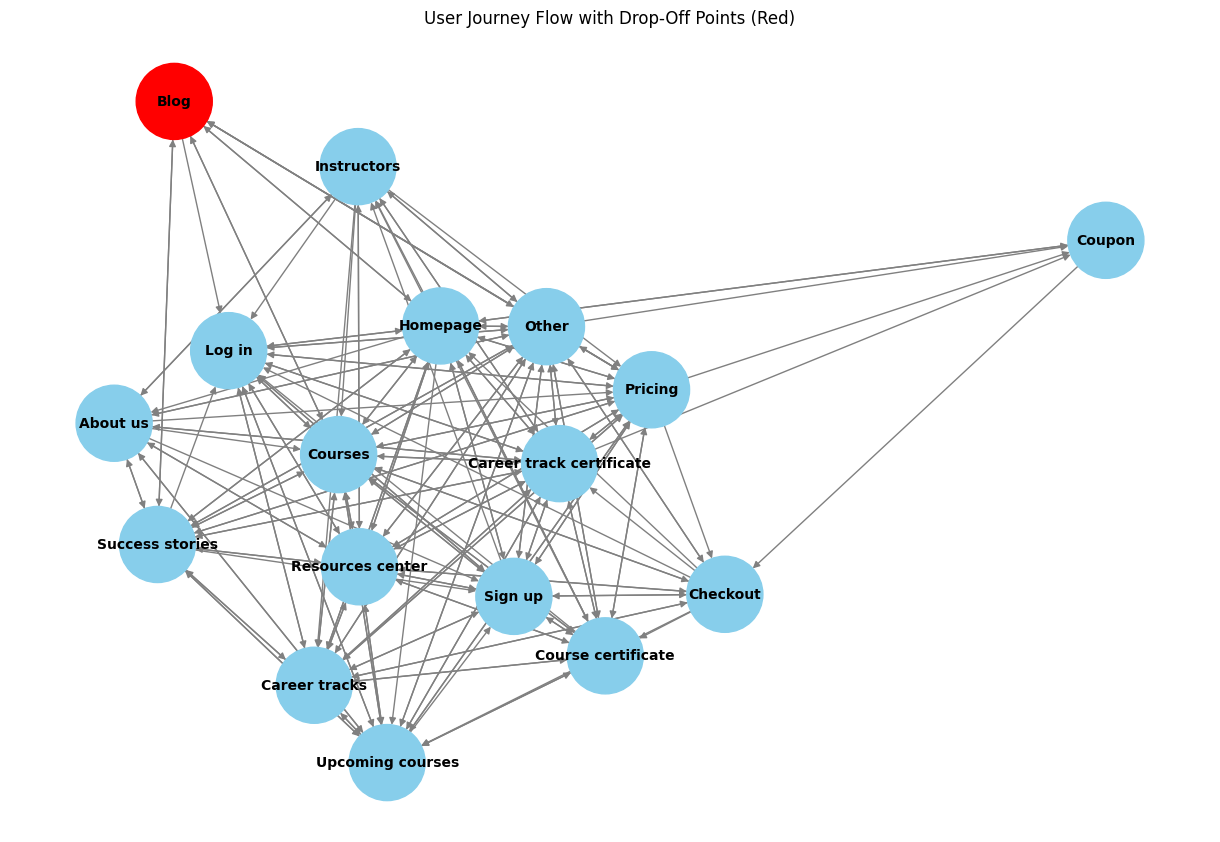

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph for the filtered journeys
G = nx.DiGraph()

# Add edges based on transitions between valid steps
for journey in filtered_journeys:
    for i in range(len(journey) - 1):
        G.add_edge(journey[i], journey[i + 1])

# Highlight drop-off points in the graph
node_colors = ['red' if node in drop_off_points else 'skyblue' for node in G.nodes()]

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # Layout for the graph
nx.draw(G, pos, with_labels=True, node_size=3000, node_color=node_colors, font_size=10, font_weight="bold", edge_color="gray")
plt.title("User Journey Flow with Drop-Off Points (Red)")

# Save the graph as an image file (e.g., PNG, JPG)
plt.savefig('user_journey_graph.png', format='png', dpi=300)  # You can change format to 'jpg' if desired

# Display the graph
plt.show()


In [28]:
# Calculate journey lengths
data['journey_length'] = data['filtered_user_journey'].apply(lambda x: len(x.split('-')) if x else 0)

# Group by conversion status (e.g., whether the journey ends with "Checkout")
data['converted'] = data['end_point'] == 'Checkout'

# Summary statistics for converting vs. non-converting users
summary_stats = data.groupby('converted')['journey_length'].agg(['mean', 'median', 'std', 'count'])
print(summary_stats)

               mean  median       std  count
converted                                   
False      1.675323     1.0  1.055531   7971
True       1.185845     1.0  0.650705   1964


In [29]:
# Create binary columns for each step
step_columns = pd.get_dummies(all_steps, prefix='step').groupby(level=0).sum()

# Combine with the original DataFrame
df_combined = pd.concat([data.reset_index(drop=True), step_columns], axis=1)

# Drop non-numeric columns (e.g., 'subscription_type', 'user_id', etc.)
numeric_columns = df_combined.select_dtypes(include=['number']).columns.tolist()

# Remove 'converted' and 'visited_Checkout', 'step_Checkout' from features
if 'converted' in numeric_columns:
    numeric_columns.remove('converted')  # Exclude 'converted' from features
if 'visited_Checkout' in numeric_columns:
    numeric_columns.remove('visited_Checkout')  # Exclude 'visited_Checkout'
if 'step_Checkout' in numeric_columns:
    numeric_columns.remove('step_Checkout')  # Exclude 'step_Checkout'

# Calculate correlations with 'converted'
correlations = df_combined[numeric_columns + ['converted']].corr()['converted']

# Sort correlations in descending order
print(correlations.sort_values(ascending=False))


converted                        1.000000
session_id                       0.207230
user_id                          0.049252
step_Pricing                     0.006381
step_Blog                       -0.019302
step_About us                   -0.023384
step_Instructors                -0.025426
step_Success stories            -0.031339
step_Upcoming courses           -0.040227
step_Course certificate         -0.063975
step_Resources center           -0.084944
step_Career track certificate   -0.086022
step_Career tracks              -0.124283
step_Courses                    -0.141642
step_Coupon                     -0.167345
step_Sign up                    -0.177897
journey_length                  -0.193448
step_Other                      -0.207996
step_Homepage                   -0.223708
step_Log in                     -0.388413
Name: converted, dtype: float64


In [30]:
# Extract binary features for each step
for step in unique_steps:
    data[f'visited_{step}'] = data['filtered_user_journey'].apply(lambda x: int(step in x.split('-')) if x else 0)

# Add journey length as a feature
data['journey_length'] = data['filtered_user_journey'].apply(lambda x: len(x.split('-')) if x else 0)

In [31]:
# Select numeric columns (visited_* columns and converted), excluding "visited_Checkout"
numeric_columns = [col for col in data.columns if col.startswith('visited_') or col == 'converted']
if 'visited_Checkout' in numeric_columns:
    numeric_columns.remove('visited_Checkout')  # Exclude "visited_Checkout"

# Separate features (X) and target variable (y)
X = data[numeric_columns].drop(columns=['converted'])  # Features
y = data['converted']  # Target variable


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

from sklearn.metrics import classification_report, roc_auc_score

# Predict on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Print ROC AUC score
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))



Classification Report:
               precision    recall  f1-score   support

       False       0.99      1.00      0.99      1600
        True       0.99      0.95      0.97       387

    accuracy                           0.99      1987
   macro avg       0.99      0.97      0.98      1987
weighted avg       0.99      0.99      0.99      1987

ROC AUC Score: 0.9989510658914729


In [32]:
# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", feature_importances)

Feature Importances:
                              Feature  Importance
1                     visited_Log in    0.279290
2                      visited_Other    0.201344
4                     visited_Coupon    0.190997
0                   visited_Homepage    0.086515
3                    visited_Sign up    0.077895
8                    visited_Courses    0.060367
6              visited_Career tracks    0.038812
5                    visited_Pricing    0.017628
7           visited_Resources center    0.016406
9   visited_Career track certificate    0.015244
11        visited_Course certificate    0.006755
13          visited_Upcoming courses    0.002740
12           visited_Success stories    0.002496
10               visited_Instructors    0.002045
15                      visited_Blog    0.000948
14                  visited_About us    0.000518


C:\Users\HP\AppData\Local\Temp\ipykernel_7780\1967579316.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


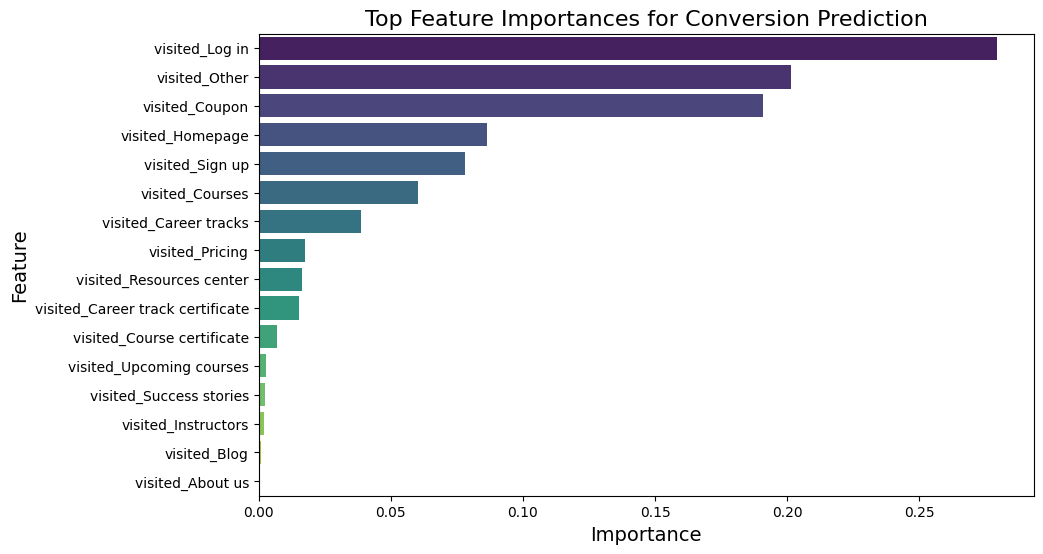

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 10
top_features = feature_importances.head(top_n)

# Set plot size
plt.figure(figsize=(10, 6))

# Create horizontal bar chart
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')

# Add labels and title
plt.title('Top Feature Importances for Conversion Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()